Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

Cell 2 — Load the final v5 dataset

In [2]:
df = pd.read_csv("synthetic_respiratory_dataset_15000_v5.csv")
df.head()

,age,sex,smoking_status,heart_rate,respiratory_rate,temperature,spo2,cough_severity,dyspnea_severity,fev1_fvc_ratio,symptom_duration_days,target_class,smoking_status_label
0,80,Male,1,117,31,38.6,94,3,3,82.4,7,Pneumonia,Ex-smoker
1,42,Female,0,96,27,37.3,95,3,3,64.3,11,Asthma,Never
2,49,Male,2,106,23,38.3,90,3,2,80.5,4,Pneumonia,Current smoker
3,32,Male,0,68,18,36.6,97,1,1,80.7,3,Healthy,Never
4,44,Female,0,92,19,36.7,96,2,0,79.9,8,Asthma,Never


Cell 3 — Basic checks

In [3]:
print(df.shape)
print(df.columns.tolist())
print()
print(df["target_class"].value_counts())
print()
print(df.isna().sum())

(15000, 13)
['age', 'sex', 'smoking_status', 'heart_rate', 'respiratory_rate', 'temperature', 'spo2', 'cough_severity', 'dyspnea_severity', 'fev1_fvc_ratio', 'symptom_duration_days', 'target_class', 'smoking_status_label']

target_class
Pneumonia    5000
Asthma       5000
Healthy      5000
Name: count, dtype: int64

age                      0
sex                      0
smoking_status           0
heart_rate               0
respiratory_rate         0
temperature              0
spo2                     0
cough_severity           0
dyspnea_severity         0
fev1_fvc_ratio           0
symptom_duration_days    0
target_class             0
smoking_status_label     0
dtype: int64


Cell 4 — Define features and target

In [4]:
drop_cols = ["target_class"]

optional_drop_cols = [
    "smoking_status_label",
    "hidden_severity_state",
    "hidden_severity_label"
]

for col in optional_drop_cols:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y = df["target_class"]

print("Number of training features:", X.shape[1])
print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Number of training features: 11

Feature columns:
['age', 'sex', 'smoking_status', 'heart_rate', 'respiratory_rate', 'temperature', 'spo2', 'cough_severity', 'dyspnea_severity', 'fev1_fvc_ratio', 'symptom_duration_days']

Target classes:
['Pneumonia' 'Asthma' 'Healthy']


Cell 5 — Encode target labels

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Class mapping:
0 -> Asthma
1 -> Healthy
2 -> Pneumonia


Cell 6 — Identify numeric and categorical columns

In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['sex']
Numeric columns: ['age', 'smoking_status', 'heart_rate', 'respiratory_rate', 'temperature', 'spo2', 'cough_severity', 'dyspnea_severity', 'fev1_fvc_ratio', 'symptom_duration_days']


Cell 7 — Preprocessing pipelines

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

Cell 8 — Train-test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)

(12000, 11) (3000, 11)


Cell 9 — Define baseline models

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

Cell 10 — Train and evaluate all models

In [10]:
results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro Precision": prec,
        "Macro Recall": rec,
        "Macro F1": f1
    })

    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Gradient Boosting,0.931333,0.931055,0.931333,0.931114
1,SVM,0.928667,0.928403,0.928667,0.928285
2,Random Forest,0.927333,0.927246,0.927333,0.927166
3,Logistic Regression,0.913000,0.912882,0.913000,0.912730
4,KNN,0.911333,0.911281,0.911333,0.910556


Cell 11 — Save the model comparison table

In [11]:
results_df.to_csv("v5_model_comparison_results.csv", index=False)
print("Saved: v5_model_comparison_results.csv")
results_df

Saved: v5_model_comparison_results.csv


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Gradient Boosting,0.931333,0.931055,0.931333,0.931114
1,SVM,0.928667,0.928403,0.928667,0.928285
2,Random Forest,0.927333,0.927246,0.927333,0.927166
3,Logistic Regression,0.913000,0.912882,0.913000,0.912730
4,KNN,0.911333,0.911281,0.911333,0.910556


Cell 12 — Classification reports

In [12]:
for name, pipe in fitted_pipelines.items():
    print("\n" + "="*70)
    print(name)
    print("="*70)

    y_pred = pipe.predict(X_test)
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4
    ))


Logistic Regression
              precision    recall  f1-score   support

      Asthma     0.8747    0.8660    0.8704      1000
     Healthy     0.9289    0.9670    0.9476      1000
   Pneumonia     0.9350    0.9060    0.9203      1000

    accuracy                         0.9130      3000
   macro avg     0.9129    0.9130    0.9127      3000
weighted avg     0.9129    0.9130    0.9127      3000


Random Forest
              precision    recall  f1-score   support

      Asthma     0.8922    0.8940    0.8931      1000
     Healthy     0.9513    0.9770    0.9640      1000
   Pneumonia     0.9382    0.9110    0.9244      1000

    accuracy                         0.9273      3000
   macro avg     0.9272    0.9273    0.9272      3000
weighted avg     0.9272    0.9273    0.9272      3000


Gradient Boosting
              precision    recall  f1-score   support

      Asthma     0.9029    0.8930    0.8979      1000
     Healthy     0.9542    0.9790    0.9664      1000
   Pneumonia     0.9

Cell 13 — Confusion matrices

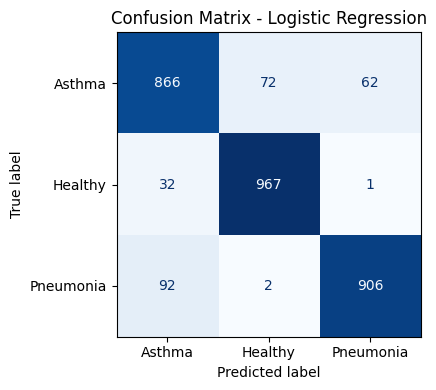

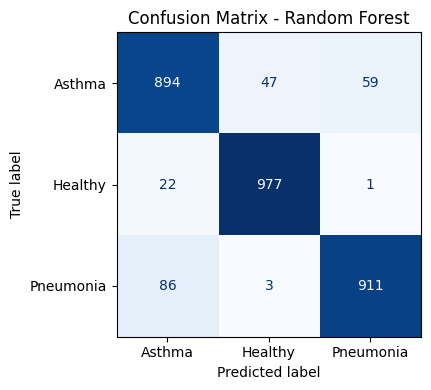

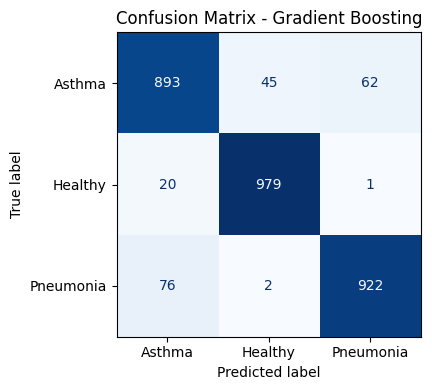

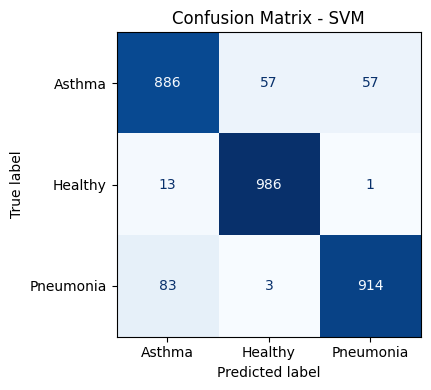

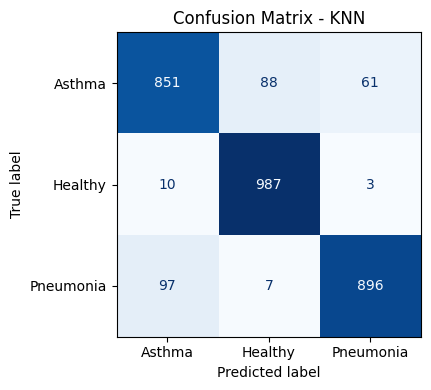

In [13]:
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

Cell 14 — Cross-validation on the best models

In [14]:
top_models = ["Random Forest", "Logistic Regression", "SVM"]

cv_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in top_models:
    pipe = fitted_pipelines[name]
    scores = cross_val_score(pipe, X, y_encoded, cv=cv, scoring="f1_macro", n_jobs=-1)

    cv_rows.append({
        "Model": name,
        "CV Macro F1 Mean": scores.mean(),
        "CV Macro F1 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by="CV Macro F1 Mean", ascending=False).reset_index(drop=True)
cv_results_df

,Model,CV Macro F1 Mean,CV Macro F1 Std
0,SVM,0.932010,0.004341
1,Random Forest,0.931065,0.003691
2,Logistic Regression,0.915810,0.005485


Cell 15 — Save CV results

In [15]:
cv_results_df.to_csv("v5_cross_validation_results.csv", index=False)
print("Saved: v5_cross_validation_results.csv")
cv_results_df

Saved: v5_cross_validation_results.csv


,Model,CV Macro F1 Mean,CV Macro F1 Std
0,SVM,0.932010,0.004341
1,Random Forest,0.931065,0.003691
2,Logistic Regression,0.915810,0.005485


Cell 16 — Feature importance for Random Forest

In [16]:
rf_pipe = fitted_pipelines["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()

importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances.head(15)

,Feature,Importance
4,num__temperature,0.166194
5,num__spo2,0.148614
8,num__fev1_fvc_ratio,0.133030
9,num__symptom_duration_days,0.121610
3,num__respiratory_rate,0.107712
0,num__age,0.087778
7,num__dyspnea_severity,0.086201
2,num__heart_rate,0.067948
6,num__cough_severity,0.060595
1,num__smoking_status,0.010369


Cell 17 — Plot top feature importances

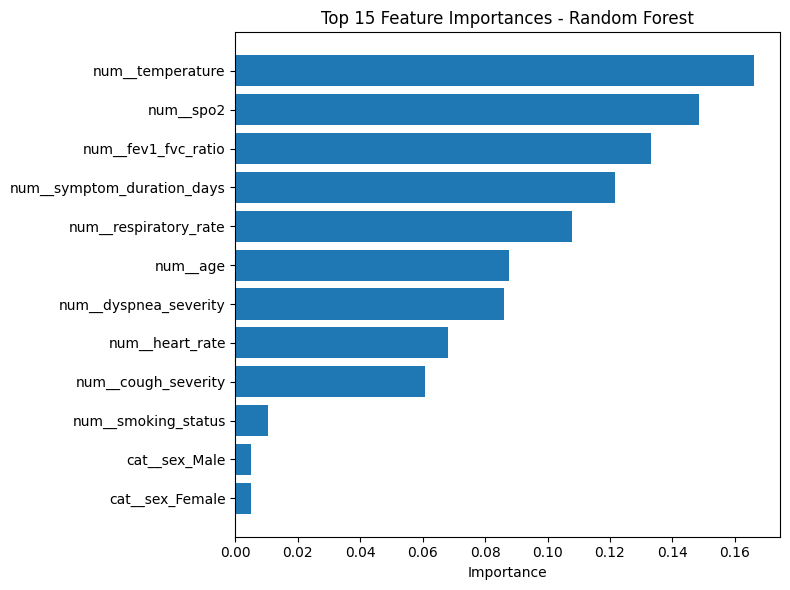

In [17]:
top_n = 15
top_imp = importances.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Cell 18 — Save feature importances

In [18]:
importances.to_csv("v5_random_forest_feature_importance.csv", index=False)
print("Saved: v5_random_forest_feature_importance.csv")

Saved: v5_random_forest_feature_importance.csv


Cell 19 — Quick interpretation helper

In [19]:
print("Best hold-out model:")
print(results_df.iloc[0])

print("\nBest CV model:")
print(cv_results_df.iloc[0])

print("\nTop 10 Random Forest features:")
print(importances.head(10))

Best hold-out model:
Model              Gradient Boosting
Accuracy                    0.931333
Macro Precision             0.931055
Macro Recall                0.931333
Macro F1                    0.931114
Name: 0, dtype: object

Best CV model:
Model                    SVM
CV Macro F1 Mean     0.93201
CV Macro F1 Std     0.004341
Name: 0, dtype: object

Top 10 Random Forest features:
                      Feature  Importance
4            num__temperature    0.166194
5                   num__spo2    0.148614
8         num__fev1_fvc_ratio    0.133030
9  num__symptom_duration_days    0.121610
3       num__respiratory_rate    0.107712
0                    num__age    0.087778
7       num__dyspnea_severity    0.086201
2             num__heart_rate    0.067948
6         num__cough_severity    0.060595
1         num__smoking_status    0.010369


Cell A — Rebuild the final deployment pipeline

In [20]:
import joblib

feature_cols = [
    "age",
    "sex",
    "smoking_status",
    "heart_rate",
    "respiratory_rate",
    "temperature",
    "spo2",
    "cough_severity",
    "dyspnea_severity",
    "fev1_fvc_ratio",
    "symptom_duration_days"
]

target_col = "target_class"

X = df[feature_cols].copy()
y = df[target_col].copy()

numeric_features = [
    "age",
    "smoking_status",
    "heart_rate",
    "respiratory_rate",
    "temperature",
    "spo2",
    "cough_severity",
    "dyspnea_severity",
    "fev1_fvc_ratio",
    "symptom_duration_days"
]

categorical_features = ["sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

final_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

final_rf_pipeline.fit(X, y)
print("Final Random Forest pipeline trained successfully.")

Final Random Forest pipeline trained successfully.


Cell B — Save the pipeline

In [21]:
joblib.dump(final_rf_pipeline, "respiratory_rf_pipeline_v5.pkl")
print("Saved: respiratory_rf_pipeline_v5.pkl")

Saved: respiratory_rf_pipeline_v5.pkl


Cell C — Quick prediction test

In [22]:
sample_input = pd.DataFrame([{
    "age": 42,
    "sex": "Female",
    "smoking_status": 0,
    "heart_rate": 96,
    "respiratory_rate": 27,
    "temperature": 37.3,
    "spo2": 95,
    "cough_severity": 3,
    "dyspnea_severity": 3,
    "fev1_fvc_ratio": 64.3,
    "symptom_duration_days": 11
}])

pred = final_rf_pipeline.predict(sample_input)[0]
proba = final_rf_pipeline.predict_proba(sample_input)[0]

print("Prediction:", pred)
print("Classes:", final_rf_pipeline.named_steps["model"].classes_)
print("Probabilities:", proba)

Prediction: Asthma
Classes: ['Asthma' 'Healthy' 'Pneumonia']
Probabilities: [0.99333333 0.         0.00666667]


In [23]:
import sklearn
print(sklearn.__version__)

1.6.1
